<div style="
    width:100%;
    background: linear-gradient(180deg, #000000, #25362a);
    color:#e6ffe6;
    padding:35px 0;
    text-align:center;
    border-radius:12px;
    border: 1px solid #00ff88;
    box-shadow: 0 0 20px rgba(0,255,136,0.15);
">

  <video autoplay loop muted playsinline
         width="600"
         style="
            border-radius:12px;
            border:1px solid #00ff88;
            box-shadow:0 0 25px rgba(0,255,136,0.25);
         ">
    <source src="https://media1.giphy.com/media/G6sJqVpD1U4jC/giphy.mp4" type="video/mp4">
  </video>

  <h3 style="color:#00ff88; margin-top:20px; letter-spacing:0.6px;">
    <b>
      Matrix-Based Solution of 2D Moment-Resisting Frames<br>
      with Axial, Flexural, and Shear Deformations Including Rigid End Offsets
    </b>
  </h3>

  <p><b>Author:</b> Msc. Ing. Carlos Andrés Celi Sánchez</p>
  <p><b>Course:</b> Matrix Structural Analysis</p>
  <p><b>Year:</b> JUN – 2026</p>

</div>


## Stiffness Matrix [Element MF] – Class-Based Implementation in Python

In [1]:
import sys
print(sys.executable)

c:\Users\norma\AppData\Local\Programs\Python\Python310\python.exe


### **Libraries**

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [3]:
# %matplotlib widget
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from repo_maxtrix_analisys import *

### **1. Purpose of This Section**
---

The purpose of this section is to formally introduce the **local stiffness matrix of a 2D MF element** and to show how this formulation can be implemented in Python using a **class-based approach**.

The explanation is intentionally structured to:
- Emphasize **conceptual understanding**
- Maintain **mathematical rigor**
- Avoid unnecessary programming abstractions
- Facilitate scalability to multiple elements

### **2. Element Matrices of a 2D MF Element**
---

#### **2.1. Local Stiffness Matrix of a 2D MF Element**
---

For a prismatic **2D MF (Moment Frame) element** considering **axial deformation, flexural deformation, shear deformation**, and the presence of **rigid end offsets**, the **local stiffness matrix** is written in a generalized form as:

$$
\mathbf{K}_e =
\begin{bmatrix}
 r      & 0        & 0        & -r     & 0         & 0 \\
 0      & t'       & b''      & 0      & -t'       & b''' \\
 0      & b''      & a''      & 0      & -b''      & a''' \\
 -r     & 0        & 0        & r      & 0         & 0 \\
 0      & -t'      & -b''     & 0      & t'        & -b''' \\
 0      & b'''     & a'''     & 0      & -b'''     & k'''
\end{bmatrix}
$$

This matrix establishes the standard linear relationship:

$$
\mathbf{F}_e = \mathbf{K}_e \, \mathbf{U}_e
$$

Where:
- $\mathbf{F}_e$ is the **local nodal force vector** of the element,
- $\mathbf{U}_e$ is the **local nodal displacement vector**,
- $\mathbf{K}_e$ is the **local stiffness matrix** of the MF element.

The six degrees of freedom associated with the element are:
- Axial displacement at node $A$, $\Delta x_A$
- Transverse displacement at node $A$, $\Delta y_A$
- Rotation at node $A$, $\theta_A$
- Axial displacement at node $B$, $\Delta x_B$
- Transverse displacement at node $B$, $\Delta y_B$
- Rotation at node $B$, $\theta_B$

---

**The coefficients appearing in the stiffness matrix account for axial, flexural, shear, and rigid-end effects and are defined as:**

$$
r = \dfrac{AE}{L}
$$

$$
G = \dfrac{E}{2(1+\nu)}
$$

$$
\beta = \dfrac{6EI}{G A L^2} \, f
$$

Where:
- $f$ is the **shear correction factor**, accounting for the non-uniform shear stress distribution over the cross section.

The remaining stiffness coefficients are expressed as:

$$
t' = \dfrac{12EI}{L^3} \, \dfrac{1}{1 + 2\beta}
$$

$$
b' = \dfrac{6EI}{L^2} \, \dfrac{1}{1 + 2\beta}
$$

$$
k' = \dfrac{2EI}{L} \, \dfrac{2 + \beta}{1 + 2\beta}
$$

$$
a' = \dfrac{2EI}{L} \, \dfrac{1 - \beta}{1 + 2\beta}
$$

---

**When rigid end offsets $d_A$ and $d_B$ are present, the modified stiffness coefficients become:**

$$
b'' = b' + t' \, d_A
$$

$$
b''' = b' + t' \, d_B
$$

$$
a'' = a' + b'(d_A + d_B) + t' d_A d_B
$$

$$
k''' = k' + 2 b' d_B + t' d_B^2
$$

These expressions allow the MF element stiffness matrix to consistently incorporate:
- Shear deformation effects through $\beta$ and $f$,
- Rigid end offsets at both element ends,
- Classical beam–column axial–flexural coupling.

This formulation is particularly suitable for **moment-resisting frame elements** used in refined matrix-based structural analysis.


### **3. Motivation for a Class-Based Representation**
---

In structural analysis, an element is not merely a numerical operation; it is a **physical entity** with:
- Material properties
- Geometric characteristics
- Governing equations

Using a class allows the element to:
- Store its own properties $(E, A, I, L)$
- Compute its stiffness matrix internally
- Be reused consistently in larger structural systems

Conceptually:
- A **function** computes a result.
- A **class** represents an object that *knows how to compute* its result.

This distinction becomes essential when dealing with multiple elements.

### **4. Class Definition: 2D MF Element Stiffness Matrix (Local Coordinates) and Coordinate Transformation Matrix**
---


### **5. Class Definition: MF Element Stiffness Matrix Container (Local Coordinates) and Coordinate Transformation Matrix**
---

Consider a structure composed of $N$ MF elements. Each element contributes a stiffness matrix of size $6 \times 6$.

To store the stiffness matrices of all elements without performing global assembly, a stacked matrix is defined as:

$$
\mathbf{K}_{\text{stacked}} \in \mathbb{R}^{6N \times 6}
$$

Where:
- $\mathbf{K}_{\text{stacked}}$ is the **stacked stiffness matrix**,
- $N$ is the **number of beam elements**,
- Each block of $6$ consecutive rows corresponds to the stiffness matrix of one beam element.

This representation is particularly useful when:
- The objective is to inspect or post-process individual element stiffness matrices,
- The number of elements is variable,
- Global assembly is intentionally deferred to a later stage.

From a matrix-structure perspective, the stacked matrix can be written as:

$$
\mathbf{K}_{\text{stacked}} =
\begin{bmatrix}
\mathbf{K}_e^{(1)} \\
\mathbf{K}_e^{(2)} \\
\vdots \\
\mathbf{K}_e^{(N)}
\end{bmatrix}
$$

Where:
- $\mathbf{K}_e^{(i)}$ is the **local stiffness matrix** of the $i$-th beam element,
- $\mathbf{K}_e^{(i)} \in \mathbb{R}^{6 \times 6}$ for all elements.

As a direct consequence, if three beam elements are considered ($N = 3$), the resulting storage matrix has dimensions:

$$
\mathbf{K}_{\text{stacked}} \in \mathbb{R}^{18 \times 6}
$$

This formulation is independent of material properties, geometry, or boundary conditions, and depends solely on the number of elements and the size of the elemental stiffness matrix.


### **Computation of Local Stiffness and Transformation Matrices for 2D MF Elements**
---

### Data Material/section properties, angles, placement vectors, and data

In [ ]:
Lc = 3.6                                                                                                            # Length of column elements
Lv = 7.0                                                                                                            # Length of beam elements
bc = 0.40
hc = 0.40
Ac = bc*hc                                                                                                      # Area for columns
bv = 0.30
hv = 0.40
Av = bv*hv                                                                                                      # Area for beams
Ic = bc*hc**3 / 12.0                                                                                                 # Inertia for columns
Iv = bv*hv**3 / 12.0                                                                                            # Inertia for beams
E = 2000000                                                                                                         # Young's modulus
L = [Lv, Lv, Lc, Lc, Lc]                                                                                            # Array of element lengths (columns and beams)
A = [Av, Av, Ac, Ac, Ac]                                                                                            # Array of cross-sectional areas (columns and beams)
I = [Iv, Iv, Ic, Ic, Ic]                                                                                            # Array of second moments of area (columns and beams)
nu = 0.20                                                                                                           # Poisson ratio
f  = 6/5                                                                                                            # Shear correction factor
da = 0.00                                                                                                           # Rigid end offset at A (local)
db = 0.00                                                                                                           # Rigid end offset at B (local)
dA = [da, da, da, da, da]                                                                                           # Rigid end offsets at A for each element
dB = [db, db, db, db, db]                                                                                           # Rigid end offsets at B for each element
thetha = [0, 0, 90, 270, 270]                                                                                       # Orientation angles for each element (degrees)

local_dof = 6                                                                                                       # Local DOF per element
Global_dof = 6                                                                                                      # Global DOF per element
nglt = 18                                                                                                            # Number of global DOF including supports
gdl = 9                                                                                                            # Number of free global DOF          

wu = 1.368
wu_e = [wu, wu, 0, 0, 0]                                                                                            # Uniformly distributed load of each element (local -y direction)

P_nodal = np.zeros((nglt, 1))                                                                                       # External nodal loads of all DOF, global coordinates (index 0 -> GDL 1)
# P_nodal[0] = 10                                                                                                   # e.g. horizontal load of 10 T at GDL 1

Lee = np.array([                                                                                                    # Placement vectors of each element
    [1,2,3,4,5,6],
    [4,5,6,7,8,9],
    [10,11,12,1,2,3],
    [4,5,6,13,14,15],
    [7,8,9,16,17,18]                                                                                                  
])

Lee_Nodos = np.array([                                                                                              # Node connectivity of each element
    [1,2],
    [2,3],
    [4,1],
    [2,5],
    [3,6]
])


element_names = [f'Elem_{i+1}' for i in range(len(Lee))]                                                            # Element labels for the table
Lee_table = pd.DataFrame(                                                                                           # Convert placement vectors to DataFrame
    Lee,                                                                                                            # Placement vector array
    index=element_names,                                                                                            # DataFrame row names
    columns=["GDLg_Ax", "GDLg_Ay", "Global_Aθ ", "GDLg_Bx", "GDLg_By", "Global_Bθ "]                                # Global DOF column names
)
print("=" * 120)                                                                                                    # Print table separator
print('Placement Vectors')                                                                                          # Print table title
print("=" * 120)                                                                                                    # Print table separator
Lee_table                                                                                                           # Display placement vectors table

Placement Vectors


,GDLg_Ax,GDLg_Ay,Global_Aθ,GDLg_Bx,GDLg_By,Global_Bθ
Elem_1,1,2,3,4,5,6
Elem_2,4,5,6,7,8,9
Elem_3,10,11,12,1,2,3
Elem_4,4,5,6,13,14,15
Elem_5,7,8,9,16,17,18


### Calculation of Local Stiffness Matrices

In [5]:
# --- Create structure container -----------------------------------------------------------------------------------
structure = Manager_K_T_elements2D()                                                                                    # Create an instance of the MF structure

# --- Add MF elements to the structure -----------------------------------------------------------------------------
for i in np.arange(0, len(L)):                                                                                      # Loop to add each element
    structure.add_element(MF_K_T_L_Element2D(E, A[i], I[i], L[i], nu=nu, f=f, dA=dA[i], dB=dB[i],                   # Add element with specified properties
                                             thetha=thetha[i]))                                                     

#### Basic Visualization of Local Stiffness Matrices for MF Elements

In [6]:
# --- Stack local stiffness matrices --------------------------------------------------------------------------------
K_all = structure.stacked_stiffness_matrices()                                                                      # Stacked stiffness matrix (6N x 6)

# --- Convert to DataFrame for visualization -----------------------------------------------------------------------
n_elem = len(structure.elements)
n_dof  = local_dof

rows = pd.MultiIndex.from_tuples(
    [(f'Elem_{e+1}', f'DOF_L_{d+1}') for e in range(n_elem) for d in range(n_dof)],
    names=['Element', 'Local DOF']
)

K_all_df = pd.DataFrame(K_all, index=rows, columns=[f'DOF_L_{i}' for i in np.arange(1, K_all.shape[1] + 1)])        # Convert to DataFrame for better visualization
K_all_df.head(len(K_all_df))                                                                                        # Display stacked matrices

DOF_L_1      DOF_L_2      DOF_L_3       DOF_L_4  \
Element Local DOF                                                         
Elem_1  DOF_L_1    34285.714286     0.000000     0.000000 -34285.714286   
        DOF_L_2        0.000000   111.342559   389.698958      0.000000   
        DOF_L_3        0.000000   389.698958  1821.089209      0.000000   
        DOF_L_4   -34285.714286     0.000000     0.000000  34285.714286   
        DOF_L_5        0.000000  -111.342559  -389.698958      0.000000   
        DOF_L_6        0.000000   389.698958   906.803494      0.000000   
Elem_2  DOF_L_1    34285.714286     0.000000     0.000000 -34285.714286   
        DOF_L_2        0.000000   111.342559   389.698958      0.000000   
        DOF_L_3        0.000000   389.698958  1821.089209      0.000000   
        DOF_L_4   -34285.714286     0.000000     0.000000  34285.714286   
        DOF_L_5        0.000000  -111.342559  -389.698958      0.000000   
        DOF_L_6        0.000000   389.698958   906.803494      0.000000   
Elem_3  DOF_L_1    88888.888889     0.000000     0.000000 -88888.888889   
        DOF_L_2        0.000000  1075.095415  1935.171746      0.000000   
        DOF_L_3        0.000000  1935.171746  4668.494329      0.000000   
        DOF_L_4   -88888.888889     0.000000     0.000000  88888.888889   
        DOF_L_5        0.000000 -1075.095415 -1935.171746      0.000000   
        DOF_L_6        0.000000  1935.171746  2298.123959      0.000000   
Elem_4  DOF_L_1    88888.888889     0.000000     0.000000 -88888.888889   
        DOF_L_2        0.000000  1075.095415  1935.171746      0.000000   
        DOF_L_3        0.000000  1935.171746  4668.494329      0.000000   
        DOF_L_4   -88888.888889     0.000000     0.000000  88888.888889   
        DOF_L_5        0.000000 -1075.095415 -1935.171746      0.000000   
        DOF_L_6        0.000000  1935.171746  2298.123959      0.000000   
Elem_5  DOF_L_1    88888.888889     0.000000     0.000000 -88888.888889   
        DOF_L_2        0.000000  1075.095415  1935.171746      0.000000   
        DOF_L_3        0.000000  1935.171746  4668.494329      0.000000   
        DOF_L_4   -88888.888889     0.000000     0.000000  88888.888889   
        DOF_L_5        0.000000 -1075.095415 -1935.171746      0.000000   
        DOF_L_6        0.000000  1935.171746  2298.123959      0.000000   

                       DOF_L_5      DOF_L_6  
Element Local DOF                            
Elem_1  DOF_L_1       0.000000     0.000000  
        DOF_L_2    -111.342559   389.698958  
        DOF_L_3    -389.698958   906.803494  
        DOF_L_4       0.000000     0.000000  
        DOF_L_5     111.342559  -389.698958  
        DOF_L_6    -389.698958  1821.089209  
Elem_2  DOF_L_1       0.000000     0.000000  
        DOF_L_2    -111.342559   389.698958  
        DOF_L_3    -389.698958   906.803494  
        DOF_L_4       0.000000     0.000000  
        DOF_L_5     111.342559  -389.698958  
        DOF_L_6    -389.698958  1821.089209  
Elem_3  DOF_L_1       0.000000     0.000000  
        DOF_L_2   -1075.095415  1935.171746  
        DOF_L_3   -1935.171746  2298.123959  
        DOF_L_4       0.000000     0.000000  
        DOF_L_5    1075.095415 -1935.171746  
        DOF_L_6   -1935.171746  4668.494329  
Elem_4  DOF_L_1       0.000000     0.000000  
        DOF_L_2   -1075.095415  1935.171746  
        DOF_L_3   -1935.171746  2298.123959  
        DOF_L_4       0.000000     0.000000  
        DOF_L_5    1075.095415 -1935.171746  
        DOF_L_6   -1935.171746  4668.494329  
Elem_5  DOF_L_1       0.000000     0.000000  
        DOF_L_2   -1075.095415  1935.171746  
        DOF_L_3   -1935.171746  2298.123959  
        DOF_L_4       0.000000     0.000000  
        DOF_L_5    1075.095415 -1935.171746  
        DOF_L_6   -1935.171746  4668.494329

#### Optionally, a styling function is created for the DataFrame containing the local-coordinate stiffness matrices of each element

In [7]:
K_all_df.head(len(K_all_df))                                                                                        # Display stacked matrices
def style_by_element(df):                                                                                           # Define styling function                                        
    elems = df.index.get_level_values(0)                                                                            # Get 'Element' level from MultiIndex   
    colors = ["#9b8bf8","#ffb4b4"]                                                                                  # Define a simple color palette

    styles = pd.DataFrame('', index=df.index, columns=df.columns)                                                   # Initialize styles DataFrame

    for i, e in enumerate(elems.unique()):                                                                          # loop through unique elements                                                                                                                                                                               
        c = colors[i % len(colors)]                                                                                 # Select color from palette
        mask = (elems == e)                                                                                         # Create mask for current element   
        styles.loc[mask, :] = f'background-color: {c}25'                                                            # Apply background color with transparency                                                                               

    return styles                                                                                                   # Return the styles DataFrame

K_all_df_styled = K_all_df.style.apply(style_by_element, axis=None)\
                                .format("{:,.3f}")                                                                  # Apply styling and formatting

K_all_df_styled                                                                                                     # Display styled DataFrame

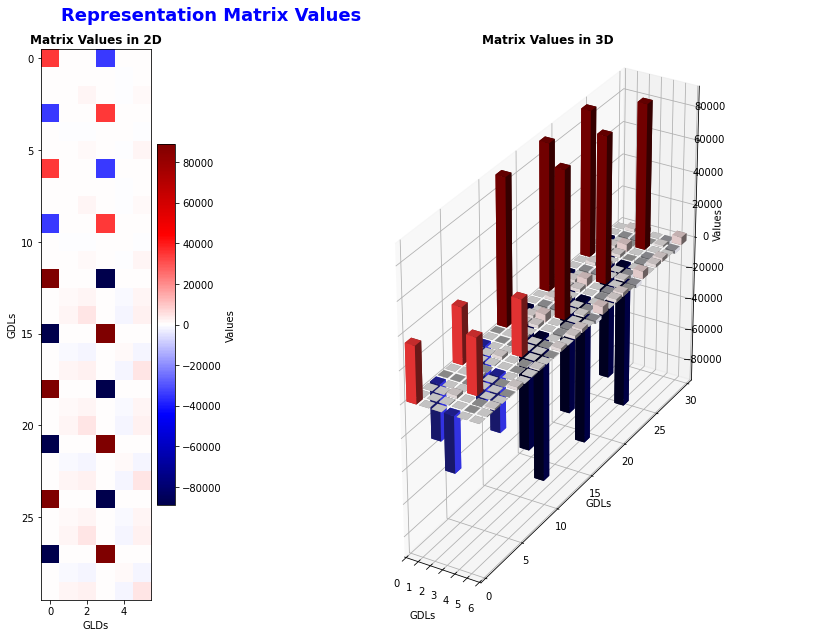

In [8]:
visualM = M_visual_2D_3D(K_all)
visualM.M_visual()

#### Example: Extraction of the Stiffness Matrix (local cordinates) of an Individual Element


In [9]:
if len(structure.elements) > 0:                                                                                     # Check if elements were added to the structure 
    n_elem = len(structure.elements)                                                                                # Get the number of elements in the structure
    print(f"\x1b[1;32m✅ The element stiffness matrices in local coordinates have been generated.\x1b[0m")          # Print success message with green color
    print(f"🧩 Number of MF elements in the structure: \x1b[1;34m{n_elem}\x1b[0m")                                  # Print number of elements with blue color
else:
    print(f"\x1b[1;31m🚫 Failed to generate element stiffness matrices in local coordinates.\x1b[0m")               # Print error message with red color              

✅ The element stiffness matrices in local coordinates have been generated.
🧩 Number of MF elements in the structure: 5


In [10]:
num_elem = 3                                                                                                        # Number of elements to display

if num_elem > len(structure.elements):                                                                              # Check if requested number of elements exceeds available
    print(f"\x1b[1;33m⚠️ Requested number of elements exceeds available.\x1b[0m")                                   # Display warning and show all available elements
else:
    elemL = structure.elements[num_elem-1].stiffness_matrix_MF_EI_AE_GAf_da_db()                                                  # Stiffness matrix of the second element      
    rows = pd.MultiIndex.from_tuples(
        [(f'Elem_{num_elem}', f'DOF_L_{d+1}') for e in range(1) for d in range(n_dof)],
        names=['Element', 'Local DOF']
    )      
    rows       
                                                                                
    elemL_df = pd.DataFrame(elemL, index=rows, columns=[f'DOF_{i}' for i in np.arange(1, elemL.shape[1] + 1)])      # Convert to DataFrame for better visualization
elemL_df.head(len(elemL_df))                                                                                        # Display the stiffness matrix of the second element                

DOF_1        DOF_2        DOF_3         DOF_4  \
Element Local DOF                                                         
Elem_3  DOF_L_1    88888.888889     0.000000     0.000000 -88888.888889   
        DOF_L_2        0.000000  1075.095415  1935.171746      0.000000   
        DOF_L_3        0.000000  1935.171746  4668.494329      0.000000   
        DOF_L_4   -88888.888889     0.000000     0.000000  88888.888889   
        DOF_L_5        0.000000 -1075.095415 -1935.171746      0.000000   
        DOF_L_6        0.000000  1935.171746  2298.123959      0.000000   

                         DOF_5        DOF_6  
Element Local DOF                            
Elem_3  DOF_L_1       0.000000     0.000000  
        DOF_L_2   -1075.095415  1935.171746  
        DOF_L_3   -1935.171746  2298.123959  
        DOF_L_4       0.000000     0.000000  
        DOF_L_5    1075.095415 -1935.171746  
        DOF_L_6   -1935.171746  4668.494329

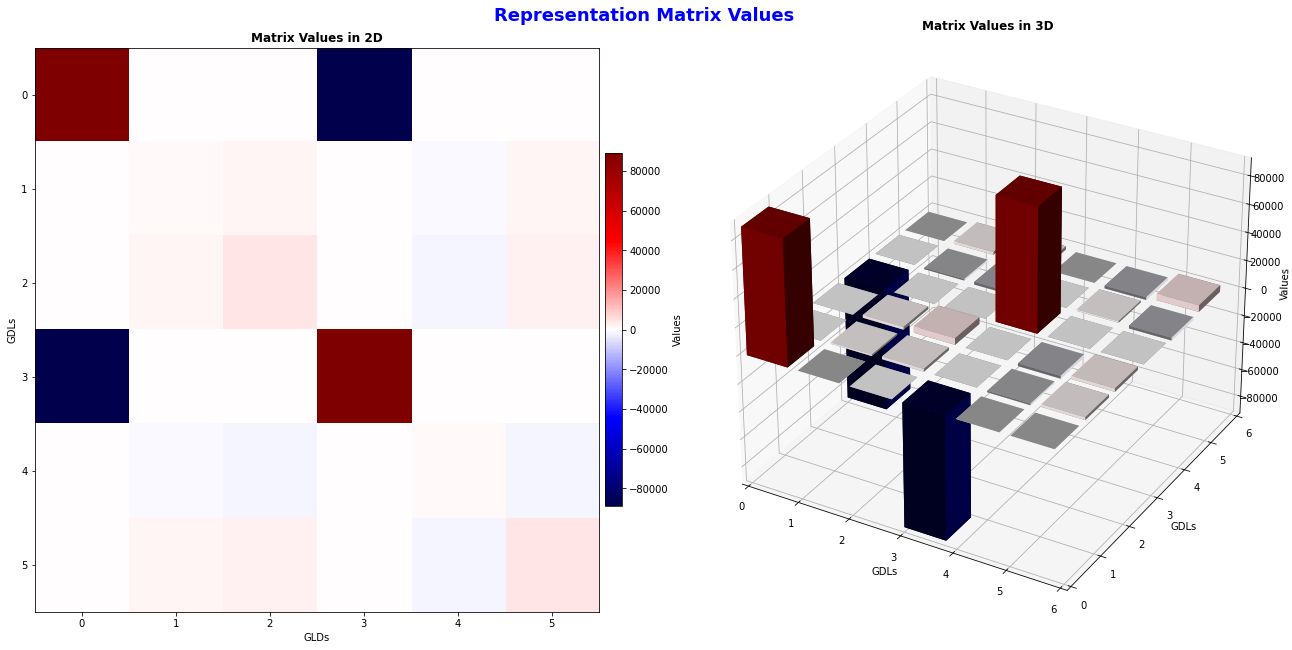

In [11]:
visualM = M_visual_2D_3D(elemL)
visualM.M_visual()

### Calculation of Matrix Transformations for MF Elements

In [12]:
# --- Stack Transformation matrices --------------------------------------------------------------------------------
T_all = structure.stacked_transformation_matrices()                                                                 # Stacked transformation matrix (6N x 6)

# --- Convert to DataFrame for visualization -----------------------------------------------------------------------
rows = pd.MultiIndex.from_tuples(
    [(f'Elem_{e+1}', f'DOF_L_G_{d+1}') for e in range(n_elem) for d in range(n_dof)],
    names=['Element', 'Local - Global DOF']
)

T_all_df = pd.DataFrame(T_all, index=rows, columns=[f'DOF_L_G_{i}' for i in np.arange(1, T_all.shape[1] + 1)])      # Convert to DataFrame for better visualization
T_all_df.head(len(T_all_df))                                                                                        # Display stacked matrices

DOF_L_G_1     DOF_L_G_2  DOF_L_G_3  \
Element Local - Global DOF                                          
Elem_1  DOF_L_G_1           1.000000e+00 -0.000000e+00        0.0   
        DOF_L_G_2           0.000000e+00  1.000000e+00        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   
Elem_2  DOF_L_G_1           1.000000e+00 -0.000000e+00        0.0   
        DOF_L_G_2           0.000000e+00  1.000000e+00        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   
Elem_3  DOF_L_G_1           6.123234e-17 -1.000000e+00        0.0   
        DOF_L_G_2           1.000000e+00  6.123234e-17        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   
Elem_4  DOF_L_G_1          -1.836970e-16  1.000000e+00        0.0   
        DOF_L_G_2          -1.000000e+00 -1.836970e-16        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   
Elem_5  DOF_L_G_1          -1.836970e-16  1.000000e+00        0.0   
        DOF_L_G_2          -1.000000e+00 -1.836970e-16        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   

                               DOF_L_G_4     DOF_L_G_5  DOF_L_G_6  
Element Local - Global DOF                                         
Elem_1  DOF_L_G_1           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_2           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_3           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_4           1.000000e+00 -0.000000e+00        0.0  
        DOF_L_G_5           0.000000e+00  1.000000e+00        0.0  
        DOF_L_G_6           0.000000e+00  0.000000e+00        1.0  
Elem_2  DOF_L_G_1           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_2           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_3           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_4           1.000000e+00 -0.000000e+00        0.0  
        DOF_L_G_5           0.000000e+00  1.000000e+00        0.0  
        DOF_L_G_6           0.000000e+00  0.000000e+00        1.0  
Elem_3  DOF_L_G_1           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_2           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_3           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_4           6.123234e-17 -1.000000e+00        0.0  
        DOF_L_G_5           1.000000e+00  6.123234e-17        0.0  
        DOF_L_G_6           0.000000e+00  0.000000e+00        1.0  
Elem_4  DOF_L_G_1           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_2           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_3           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_4          -1.836970e-16  1.000000e+00        0.0  
        DOF_L_G_5          -1.000000e+00 -1.836970e-16        0.0  
        DOF_L_G_6           0.000000e+00  0.000000e+00        1.0  
Elem_5  DOF_L_G_1           0.000000e+00  0.000000e+00

#### Example: Extraction of the Transformation Matrix of an Individual Element

In [13]:
if len(structure.elements) > 0:                                                                                     # Check if elements were added to the structure 
    n_elem = len(structure.elements)                                                                                # Get the number of elements in the structure
    print(f"\x1b[1;32m✅ The element transformation matrices have been generated.\x1b[0m")                         # Print success message with green color
    print(f"🧩 Number of MF elements in the structure: \x1b[1;34m{n_elem}\x1b[0m")                                  # Print number of elements with blue color
else:
    print(f"\x1b[1;31m🚫 Failed to generate element transformation matrices.\x1b[0m")                               # Print error message with red color  

✅ The element transformation matrices have been generated.
🧩 Number of MF elements in the structure: 5


In [14]:
num_elem = 3                                                                                                        # Number of elements to display
if num_elem > len(structure.elements):                                                                              # Check if requested number of elements exceeds available
    print(f"\x1b[1;33m⚠️ Requested number of elements exceeds available.\x1b[0m")                                   # Display warning and show all available elements
else:
    elemT = structure.elements[num_elem-1].transformation_matrix_2D()                                               # Transformation matrix of the "n" element      
    rows = pd.MultiIndex.from_tuples(
        [(f'Elem_{num_elem}', f'DOF_L_G_{d+1}') for e in range(1) for d in range(n_dof)],
        names=['Element', 'Local - Global DOF']
    )      
    rows       
                                                                                
    elemT_df = pd.DataFrame(elemT, index=rows, columns=[f'DOF_L_G_{i}' for i in np.arange(1, elemT.shape[1] + 1)])  # Convert to DataFrame for better visualization
elemT_df.head(len(elemT_df))                                                                                        # Display the transformation matrix of the "n" element 

DOF_L_G_1     DOF_L_G_2  DOF_L_G_3  \
Element Local - Global DOF                                          
Elem_3  DOF_L_G_1           6.123234e-17 -1.000000e+00        0.0   
        DOF_L_G_2           1.000000e+00  6.123234e-17        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   

                               DOF_L_G_4     DOF_L_G_5  DOF_L_G_6  
Element Local - Global DOF                                         
Elem_3  DOF_L_G_1           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_2           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_3           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_4           6.123234e-17 -1.000000e+00        0.0  
        DOF_L_G_5           1.000000e+00  6.123234e-17        0.0  
        DOF_L_G_6           0.000000e+00  0.000000e+00        1.0

### Stiffness Matrix in Global Coordinates

In [15]:
Keg_all = []                                                                                                        # Empty list to store global element stiffness matrices
for i in np.arange(0,n_elem,1):                                                                                     # Loop through each element
    Telem = structure.elements[i].transformation_matrix_2D()                                                    # Transformation matrix of element i
    Kelem = structure.elements[i].stiffness_matrix_MF_EI_AE_GAf_da_db()                                                         # Local stiffness matrix of element i
    Keg_all.append(Telem@Kelem@Telem.T)                                                                             # Transform local stiffness matrix to global coordinates

rows = pd.MultiIndex.from_tuples(                                                                                   # Create hierarchical index for global element matrices
    [
        (f'Elem_{e+1}', f'GDLg_{int(gdl)}')                                                                         # Element and global DOF labels
        for e in range(n_elem)                                                                                      # Loop through each element
        for gdl in Lee[e]                                                                                           # Loop through the placement vector of each element
    ],
    names=['Element', 'Placement Vector']                                                                           # Index level names
)

Keg_stack = np.vstack(Keg_all)                                                                                      # Stack all global element stiffness matrices
Keg_stack_df = pd.DataFrame(Keg_stack, index=rows,columns=[f'GLDg' for i in range(Global_dof)])                     # Convert stacked matrices to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Global Stiffness Matrices')                                                                                  # Print table title
print("=" * 120)                                                                                                    # Print table separator
Keg_stack_df.round(3)                                                                                               # Display rounded global element matrices

Global Stiffness Matrices


GLDg       GLDg      GLDg       GLDg  \
Element Placement Vector                                              
Elem_1  GDLg_1            34285.714      0.000     0.000 -34285.714   
        GDLg_2                0.000    111.343   389.699      0.000   
        GDLg_3                0.000    389.699  1821.089      0.000   
        GDLg_4           -34285.714      0.000     0.000  34285.714   
        GDLg_5                0.000   -111.343  -389.699      0.000   
        GDLg_6                0.000    389.699   906.803      0.000   
Elem_2  GDLg_4            34285.714      0.000     0.000 -34285.714   
        GDLg_5                0.000    111.343   389.699      0.000   
        GDLg_6                0.000    389.699  1821.089      0.000   
        GDLg_7           -34285.714      0.000     0.000  34285.714   
        GDLg_8                0.000   -111.343  -389.699      0.000   
        GDLg_9                0.000    389.699   906.803      0.000   
Elem_3  GDLg_10            1075.095      0.000 -1935.172  -1075.095   
        GDLg_11               0.000  88888.889     0.000     -0.000   
        GDLg_12           -1935.172      0.000  4668.494   1935.172   
        GDLg_1            -1075.095     -0.000  1935.172   1075.095   
        GDLg_2               -0.000 -88888.889    -0.000      0.000   
        GDLg_3            -1935.172      0.000  2298.124   1935.172   
Elem_4  GDLg_4             1075.095      0.000  1935.172  -1075.095   
        GDLg_5                0.000  88888.889    -0.000     -0.000   
        GDLg_6             1935.172     -0.000  4668.494  -1935.172   
        GDLg_13           -1075.095     -0.000 -1935.172   1075.095   
        GDLg_14              -0.000 -88888.889     0.000      0.000   
        GDLg_15            1935.172     -0.000  2298.124  -1935.172   
Elem_5  GDLg_7             1075.095      0.000  1935.172  -1075.095   
        GDLg_8                0.000  88888.889    -0.000     -0.000   
        GDLg_9             1935.172     -0.000  4668.494  -1935.172   
        GDLg_16           -1075.095     -0.000 -1935.172   1075.095   
        GDLg_17              -0.000 -88888.889     0.000      0.000   
        GDLg_18            1935.172     -0.000  2298.124  -1935.172   

                               GLDg      GLDg  
Element Placement Vector                       
Elem_1  GDLg_1                0.000     0.000  
        GDLg_2             -111.343   389.699  
        GDLg_3             -389.699   906.803  
        GDLg_4                0.000     0.000  
        GDLg_5              111.343  -389.699  
        GDLg_6             -389.699  1821.089  
Elem_2  GDLg_4                0.000     0.000  
        GDLg_5             -111.343   389.699  
        GDLg_6             -389.699   906.803  
        GDLg_7                0.000     0.000  
        GDLg_8              111.343  -389.699  
        GDLg_9             -389.699  1821.089  
Elem_3  GDLg_10              -0.000 -1935.172  
        GDLg_11          -88888.889     0.000  
        GDLg_12              -0.000  2298.124  
        GDLg_1                0.000  1935.172  
        GDLg_2            88888.889    -0.000  
        GDLg_3               -0.000  4668.494  
Elem_4  GDLg_4               -0.000  1935.172  
        GDLg_5           -88888.889    -0.000  
        GDLg_6                0.000  2298.124  
        GDLg_13               0.000 -1935.172  
        GDLg_14           88888.889     0.000  
        GDLg_15               0.000  4668.494  
Elem_5  GDLg_7               -0.000  1935.172  
        GDLg_8           -88888.889    -0.000  
        GDLg_9                0.000  2298.124  
        GDLg_16               0.000 -1935.172  
        GDLg_17           88888.889     0.000  
        GDLg_18               0.000  4668.494

### Stiffness Matrix of the Structure.

#### Initialize Stiffness Matrix of the Structure

In [16]:
S = np.zeros((nglt, nglt))                                                                                          # Initialize global Structure stiffness matrix
rowsS = pd.Index(f'GDLg_{i+1}' for i in range(nglt))                                                                # Global DOF labels
S_df = pd.DataFrame(S,index= rowsS, columns=[f'GDLg_{i+1}' for i in range(nglt)])                                   # Convert global stiffness matrix to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Initialize global Structure stiffness matrix')                                                               # Print table title
print("=" * 120)                                                                                                    # Print table separator
S_df.round(3)         

Initialize global Structure stiffness matrix


,GDLg_1,GDLg_2,GDLg_3,GDLg_4,GDLg_5,GDLg_6,GDLg_7,GDLg_8,GDLg_9,GDLg_10,GDLg_11,GDLg_12,GDLg_13,GDLg_14,GDLg_15,GDLg_16,GDLg_17,GDLg_18
GDLg_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Assemble Stiffness Matrices of the Structure

In [17]:
for e in range(n_elem):                                                                                             # Loop through each element
    lee = Lee[e]                                                                                                    # Placement vector of element e
    Ke = Keg_all[e]                                                                                                 # Global stiffness matrix of element e
    S_assambler = Assembler(lee = lee, K = Ke, S = S, nglt= nglt)                                                   # Create assembler object for element e
    S = S_assambler.assambler_due_lee()                                                                             # Assemble element stiffness into the global matrix
S_df = pd.DataFrame(S,index= rowsS, columns=[f'GDLg_{i+1}' for i in range(nglt)])                                   # Convert assembled stiffness matrix to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Global Structure Stiffness Matrix')                                                                          # Print table title
print("=" * 120)                                                                                                    # Print table separator
S_df.round(3)                                                                                                       # Display rounded assembled stiffness matrix

Global Structure Stiffness Matrix


,GDLg_1,GDLg_2,GDLg_3,GDLg_4,GDLg_5,GDLg_6,GDLg_7,GDLg_8,GDLg_9,GDLg_10,GDLg_11,GDLg_12,GDLg_13,GDLg_14,GDLg_15,GDLg_16,GDLg_17,GDLg_18
GDLg_1,35360.810,0.000,1935.172,-34285.714,0.000,0.000,0.000,0.000,0.000,-1075.095,-0.000,1935.172,0.000,0.000,0.000,0.000,0.000,0.000
GDLg_2,0.000,89000.231,389.699,0.000,-111.343,389.699,0.000,0.000,0.000,-0.000,-88888.889,-0.000,0.000,0.000,0.000,0.000,0.000,0.000
GDLg_3,1935.172,389.699,6489.584,0.000,-389.699,906.803,0.000,0.000,0.000,-1935.172,0.000,2298.124,0.000,0.000,0.000,0.000,0.000,0.000
GDLg_4,-34285.714,0.000,0.000,69646.524,0.000,1935.172,-34285.714,0.000,0.000,0.000,0.000,0.000,-1075.095,-0.000,1935.172,0.000,0.000,0.000
GDLg_5,0.000,-111.343,-389.699,0.000,89111.574,-0.000,0.000,-111.343,389.699,0.000,0.000,0.000,-0.000,-88888.889,-0.000,0.000,0.000,0.000
GDLg_6,0.000,389.699,906.803,1935.172,-0.000,8310.673,0.000,-389.699,906.803,0.000,0.000,0.000,-1935.172,0.000,2298.124,0.000,0.000,0.000
GDLg_7,0.000,0.000,0.000,-34285.714,0.000,0.000,35360.810,0.000,1935.172,0.000,0.000,0.000,0.000,0.000,0.000,-1075.095,-0.000,1935.172
GDLg_8,0.000,0.000,0.000,0.000,-111.343,-389.699,0.000,89000.231,-389.699,0.000,0.000,0.000,0.000,0.000,0.000,-0.000,-88888.889,-0.000
GDLg_9,0.000,0.000,0.000,0.000,389.699,906.803,1935.172,-389.699,6489.584,0.000,0.000,0.000,0.000,0.000,0.000,-1935.172,0.000,2298.124
GDLg_10,-1075.095,-0.000,-1935.172,0.000,0.000,0.000,0.000,0.000,0.000,1075.095,0.000,-1935.172,0.000,0.000,0.000,0.000,0.000,0.000


#### Vizualizer "S"

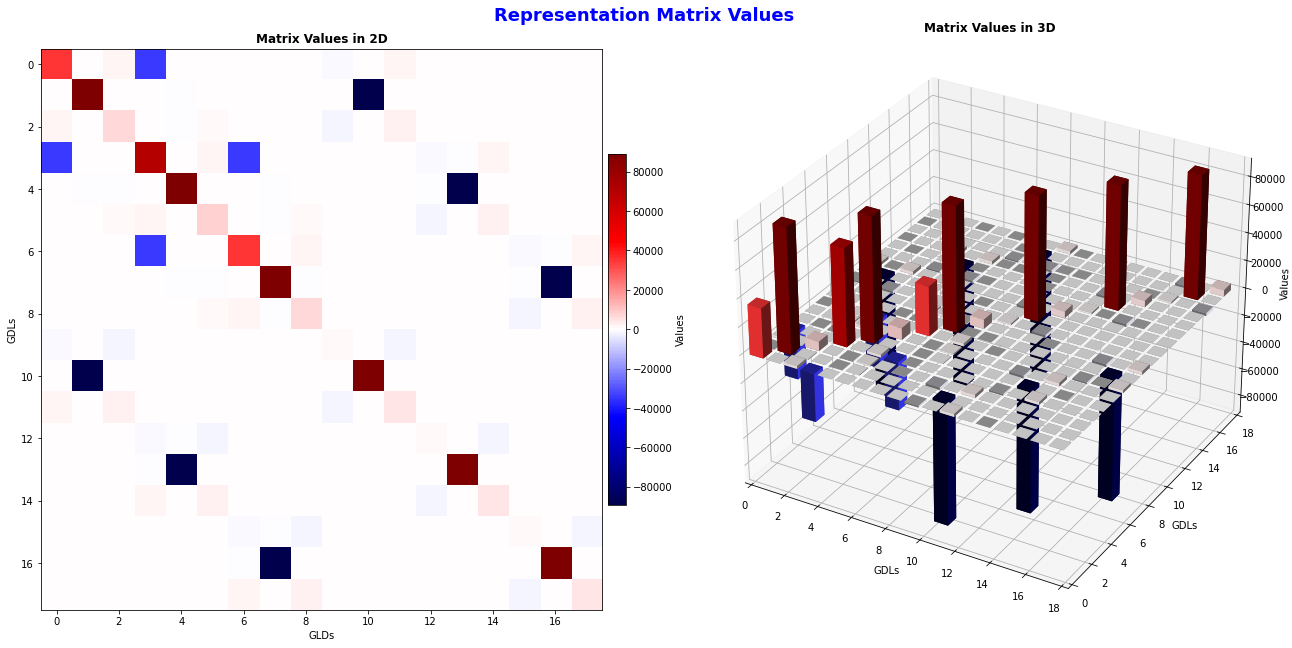

In [18]:
S_vizual = M_visual_2D_3D(S)
S_vizual.M_visual()


#### SLL

In [19]:
SLL = S[0:gdl,0:gdl]                                                                                                # Extract stiffness submatrix for free global DOF
SLL_df = pd.DataFrame(SLL,index= rowsS[0:gdl], columns=[f'GDLg_{i+1}' for i in range(gdl)])                         # Convert stiffness matrix (SLL) to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Global Structure Stiffness Matrix, SLL')                                                                     # Print table title
print("=" * 120)                                                                                                    # Print table separator
SLL_df.round(3)                                                                                                     # Display rounded SLL stiffness matrix

Global Structure Stiffness Matrix, SLL


,GDLg_1,GDLg_2,GDLg_3,GDLg_4,GDLg_5,GDLg_6,GDLg_7,GDLg_8,GDLg_9
GDLg_1,35360.810,0.000,1935.172,-34285.714,0.000,0.000,0.000,0.000,0.000
GDLg_2,0.000,89000.231,389.699,0.000,-111.343,389.699,0.000,0.000,0.000
GDLg_3,1935.172,389.699,6489.584,0.000,-389.699,906.803,0.000,0.000,0.000
GDLg_4,-34285.714,0.000,0.000,69646.524,0.000,1935.172,-34285.714,0.000,0.000
GDLg_5,0.000,-111.343,-389.699,0.000,89111.574,-0.000,0.000,-111.343,389.699
GDLg_6,0.000,389.699,906.803,1935.172,-0.000,8310.673,0.000,-389.699,906.803
GDLg_7,0.000,0.000,0.000,-34285.714,0.000,0.000,35360.810,0.000,1935.172
GDLg_8,0.000,0.000,0.000,0.000,-111.343,-389.699,0.000,89000.231,-389.699
GDLg_9,0.000,0.000,0.000,0.000,389.699,906.803,1935.172,-389.699,6489.584


#### Vizualizer "SLL"

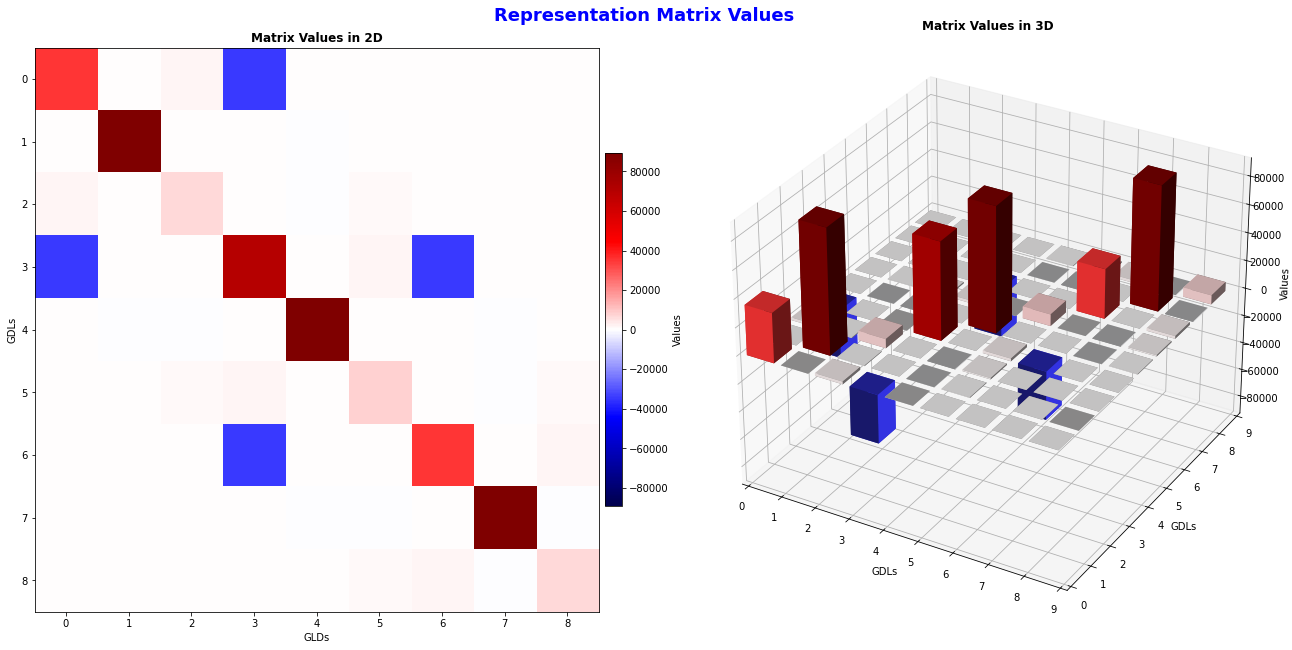

In [20]:
SLL3d = M_visual_2D_3D(SLL)                                                                                         # Create 3D visualization object for the reduced stiffness matrix
SLL3d.M_visual()                                                                                                    # Display reduced stiffness matrix as a 3D plot

### Calculation of Global Displacement.

#### Fixed-End Actions (aep) for each Element
---

Each element carries its own uniformly distributed load $w_u$ (vector `wu_e`). The fixed-end actions in local coordinates follow the same sign convention used in the deduction of the element stiffness matrix:

$$
\{aep\}_{L} =
\begin{bmatrix}
0 & \dfrac{w_u L}{2} & \dfrac{w_u L^2}{12} & 0 & \dfrac{w_u L}{2} & -\dfrac{w_u L^2}{12}
\end{bmatrix}^{T}
$$

When the element has rigid end offsets $d_A$ and $d_B$, the actions of the flexible span $L$ are transferred to the nodes through the rigid arms, $M_A = M_A' + d_A V_A$ and $M_B = M_B' - d_B V_B$, and the load acting over each rigid arm is added as a cantilever reaction ($w_u d_A$, $w_u d_A^2/2$ at $A$; $w_u d_B$, $-w_u d_B^2/2$ at $B$). With $d_A = d_B = 0$ the expression above is recovered.

The vector is transformed to global coordinates with the transformation matrix of each element:

$$
\{aep\}_{G} = [T_e] \, \{aep\}_{L}
$$


In [21]:
aep_L_all = []                                                                                                      # Empty list to store local aep vectors
aep_G_all = []                                                                                                      # Empty list to store global aep vectors
for e in np.arange(0, n_elem, 1):                                                                                   # Loop through each element
    aep_e = AEP_MF_UniformLoad2D(wu_e[e], L[e], dA=dA[e], dB=dB[e])                                                 # Fixed-end actions object of element e
    aep_L_e = aep_e.aep_local()                                                                                     # aep in local coordinates
    Telem = structure.elements[e].transformation_matrix_2D()                                                        # Local-to-global transformation matrix
    aep_L_all.append(aep_L_e)                                                                                       # Store local aep vector
    aep_G_all.append(Telem @ aep_L_e)                                                                               # Store global aep vector

rows = pd.MultiIndex.from_tuples(                                                                                   # Create hierarchical index for aep vectors
    [
        (f'Elem_{e+1}', f'GDLg_{int(gdl_e)}')                                                                       # Element and global DOF labels
        for e in range(n_elem)                                                                                      # Loop through each element
        for gdl_e in Lee[e]                                                                                         # Loop through the placement vector of each element
    ],
    names=['Element', 'Placement Vector']                                                                           # Index level names
)

aep_df = pd.DataFrame(                                                                                              # Convert aep vectors to DataFrame
    {
        'aep Local [T, T.m]': np.vstack(aep_L_all).ravel(),
        'aep Global [T, T.m]': np.vstack(aep_G_all).ravel(),
    },
    index=rows
)
print("=" * 120)                                                                                                    # Print table separator
print('Fixed-End Actions [aep]')                                                                                    # Print table title
print("=" * 120)                                                                                                    # Print table separator
aep_df.round(3)                                                                                                     # Display rounded aep vectors

Fixed-End Actions [aep]


aep Local [T, T.m]  aep Global [T, T.m]
Element Placement Vector                                         
Elem_1  GDLg_1                         0.000                0.000
        GDLg_2                         4.788                4.788
        GDLg_3                         5.586                5.586
        GDLg_4                         0.000                0.000
        GDLg_5                         4.788                4.788
        GDLg_6                        -5.586               -5.586
Elem_2  GDLg_4                         0.000                0.000
        GDLg_5                         4.788                4.788
        GDLg_6                         5.586                5.586
        GDLg_7                         0.000                0.000
        GDLg_8                         4.788                4.788
        GDLg_9                        -5.586               -5.586
Elem_3  GDLg_10                        0.000                0.000
        GDLg_11                        0.000                0.000
        GDLg_12                        0.000                0.000
        GDLg_1                         0.000                0.000
        GDLg_2                         0.000                0.000
        GDLg_3                         0.000                0.000
Elem_4  GDLg_4                         0.000                0.000
        GDLg_5                         0.000                0.000
        GDLg_6                         0.000                0.000
        GDLg_13                        0.000                0.000
        GDLg_14                        0.000                0.000
        GDLg_15                        0.000                0.000
Elem_5  GDLg_7                         0.000                0.000
        GDLg_8                         0.000                0.000
        GDLg_9                         0.000                0.000
        GDLg_16                        0.000                0.000
        GDLg_17                        0.000                0.000
        GDLg_18                        0.000                0.000

#### Accumulation of Nodal Actions [Acum]
---

The fixed-end actions of the elements that share a node are superposed on the corresponding global DOF through the placement vectors. Since the aep are reactions of the fixed element, the total nodal actions are:

$$
\{P_{GDL}\}_{T} = \{P_{GDL}\} - \{aep_{GDL}\}
$$

The vector starts from the external nodal loads $\{P_{GDL}\}$ declared in the data (`P_nodal`), the $-\{aep\}$ of each element are accumulated over all DOF (including supports), and then the free DOF are extracted.


In [22]:
P_full = P_nodal.copy()                                                                                             # Start from the external nodal loads (all DOF, including supports)
for e in range(n_elem):                                                                                             # Loop through each element
    P_acum = Acum(lee = Lee[e], aep = aep_G_all[e], P = P_full, nglt = nglt)                                        # Create accumulator object for element e
    P_full = P_acum.acum_due_lee()                                                                                  # Accumulate -aep into the nodal actions vector

P = P_full[0:gdl]                                                                                                   # Nodal actions vector for free global DOF

P_full_df = pd.DataFrame(P_full, index= rowsS, columns=['P - aep [T, T.m]'])                                        # Convert nodal actions vector to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Accumulated Nodal Actions [P - aep]')                                                                        # Print table title
print("=" * 120)                                                                                                    # Print table separator
P_full_df.round(3)                                                                                                  # Display rounded nodal actions vector

Accumulated Nodal Actions [P - aep]


,"P - aep [T, T.m]"
GDLg_1,10.000
GDLg_2,-4.788
GDLg_3,-5.586
GDLg_4,0.000
GDLg_5,-9.576
GDLg_6,0.000
GDLg_7,0.000
GDLg_8,-4.788
GDLg_9,5.586
GDLg_10,0.000


#### Load Nodal Vector

In [23]:
P_df = pd.DataFrame(P,index= rowsS[0:gdl], columns=['Loads'])                                                       # Convert load vector to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Load Nodal Vector [P]')                                                                                      # Print table title
print("=" * 120)                                                                                                    # Print table separator
P_df.round(3)                                                                                                       # Display rounded load vector

Load Nodal Vector [P]


,Loads
GDLg_1,10.000
GDLg_2,-4.788
GDLg_3,-5.586
GDLg_4,0.000
GDLg_5,-9.576
GDLg_6,0.000
GDLg_7,0.000
GDLg_8,-4.788
GDLg_9,5.586


#### Global Displacement Vector

In [24]:
delta_g = np.linalg.solve(SLL, P)                                                                                   # Solve SLL @ delta_g = P for free global DOF displacements (no explicit inverse)

delta_g_full = np.vstack((delta_g, np.zeros((nglt-gdl, 1))))

delta_g_df = pd.DataFrame(delta_g_full, index = rowsS[:nglt],columns= ['delta_GDL_g [m]'])                          # Convert displacement vector to DataFrame

print("=" * 120)                                                                                                    # Print table separator
print('Global Displacements')                                                                                       # Print table title
print("=" * 120)                                                                                                    # Print table separator
delta_g_df.round(10)                                                                                                # Display rounded displacement vector
delta_g_df                                                                                                          # Display global displacement vector

Global Displacements


,delta_GDL_g [m]
GDLg_1,0.005683
GDLg_2,-0.000039
GDLg_3,-0.002429
GDLg_4,0.005432
GDLg_5,-0.000116
GDLg_6,-0.000937
GDLg_7,0.005299
GDLg_8,-0.000061
GDLg_9,-0.000585
GDLg_10,0.000000


#### Plot Global Displacement

elem_1, node i = 1 to node j = 2
elem_2, node i = 2 to node j = 3
elem_3, node i = 4 to node j = 1
elem_4, node i = 2 to node j = 5
elem_5, node i = 3 to node j = 6
Displacement range: 0.0000 to 0.6013 cm


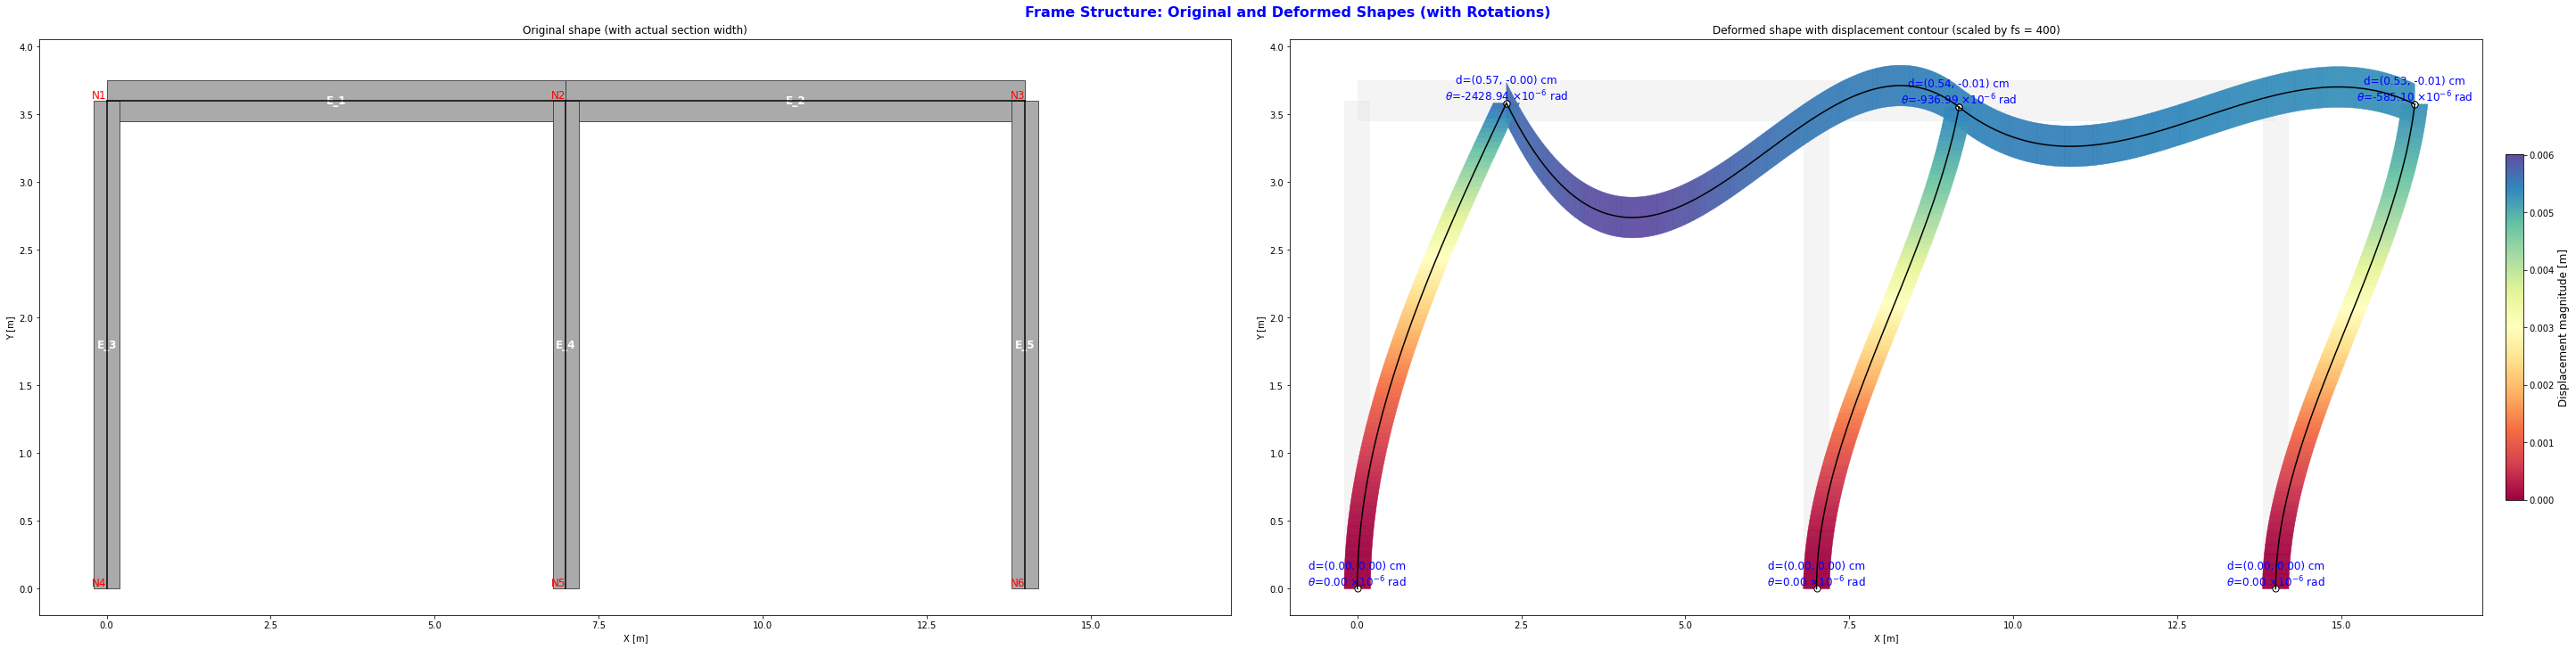

In [25]:
delta_g_values = np.asarray(delta_g_full, dtype=float).ravel()

# --- Node coordinate table: (x, y, ux, uy, rotation) -----------------
CoordNode = np.array([
    [0, Lc, delta_g_values[0], delta_g_values[1],  delta_g_values[2]],
    [Lv, Lc, delta_g_values[3], delta_g_values[4],  delta_g_values[5]],
    [2*Lv, Lc, delta_g_values[6], delta_g_values[7],  delta_g_values[8]],
    [0, 0, delta_g_values[9], delta_g_values[10], delta_g_values[11]],
    [Lv, 0, delta_g_values[12], delta_g_values[13], delta_g_values[14]],
    [2*Lv, 0, delta_g_values[15], delta_g_values[16], delta_g_values[17]],
])

# List of Colors #
'coolwarm'
'jet'
'turbo'
'viridis'
'plasma'
'inferno'
'magma'
'cividis'
'RdYlBu'
'RdYlGn'
'seismic'
'bwr'
'PiYG'
'PRGn'
'Spectral'

plotDisp = PlotGlobalDislplacemet(fs = 400,n_sub= 100,Lee_Nodos= Lee_Nodos, delta_g_full= delta_g_full,CoordNode= CoordNode, hv = bv, bc = bc, color='Spectral')
plotDisp.PlotGD_RMF()

#### Global Displacement for each Element

In [26]:
delta_g_full = np.vstack((delta_g, np.zeros((nglt-gdl, 1))))
Delta_g_elem = []

LeeE = Lee - 1

for e in np.arange(0,len(Lee),1):
    Delta_g_elem.append(delta_g_full[LeeE[e]])

Delta_g_elem = np.vstack(Delta_g_elem)


rows = pd.MultiIndex.from_tuples(                                                                                   # Create hierarchical index for global element matrices
    [
        (f'Elem_{e+1}', f'GDLg_{int(gdl)}')                                                                         # Element and global DOF labels
        for e in range(n_elem)                                                                                      # Loop through each element
        for gdl in Lee[e]                                                                                           # Loop through the placement vector of each element
    ],
    names=['Element', 'Placement Vector']                                                                           # Index level names
)


Delta_g_elem_df = pd.DataFrame(Delta_g_elem,index = rows,columns= ['Global Displacement for each Element'])
Delta_g_elem_df.round(6)

Global Displacement for each Element
Element Placement Vector                                      
Elem_1  GDLg_1                                        0.005683
        GDLg_2                                       -0.000039
        GDLg_3                                       -0.002429
        GDLg_4                                        0.005432
        GDLg_5                                       -0.000116
        GDLg_6                                       -0.000937
Elem_2  GDLg_4                                        0.005432
        GDLg_5                                       -0.000116
        GDLg_6                                       -0.000937
        GDLg_7                                        0.005299
        GDLg_8                                       -0.000061
        GDLg_9                                       -0.000585
Elem_3  GDLg_10                                       0.000000
        GDLg_11                                       0.000000
        GDLg_12                                       0.000000
        GDLg_1                                        0.005683
        GDLg_2                                       -0.000039
        GDLg_3                                       -0.002429
Elem_4  GDLg_4                                        0.005432
        GDLg_5                                       -0.000116
        GDLg_6                                       -0.000937
        GDLg_13                                       0.000000
        GDLg_14                                       0.000000
        GDLg_15                                       0.000000
Elem_5  GDLg_7                                        0.005299
        GDLg_8                                       -0.000061
        GDLg_9                                       -0.000585
        GDLg_16                                       0.000000
        GDLg_17                                       0.000000
        GDLg_18                                       0.000000

#### Local Displacement and Action Member in Local Cordinates for each Element

In [27]:
Delta_L_elem_all = []                                                                                              # Empty list to store local displacement vectors
New_L_elem = []                                                                                                    # Empty list to store current element lengths
New_L_elem_rows = []                                                                                               # Current lengths repeated for each local DOF row
MENSAJE = []
MENSAJE_rows = []
CA = []
CA_rows = []

AmL = []

MENSAJE2 = []
MENSAJE2_rows = []

for e in np.arange(0, n_elem, 1):                                                                                   # Loop through each element
# for e in np.arange(2):
    Telem = structure.elements[e].transformation_matrix_2D()                                                        # Local-to-global transformation matrix
    Delta_g_elem_e = delta_g_full[LeeE[e]]                                                                          # Global displacement vector of element e
    Delta_L_elem_e = Telem.T @ Delta_g_elem_e                                                                       # Transform global displacements to local coordinates
    
    #-------- Action Members --------
    aml = structure.elements[e].stiffness_matrix_MF_EI_AE_GAf_da_db() @ Delta_L_elem_e + aep_L_all[e]               # Am = K_L @ Delta_L + aep_L

    Delta_L_elem_all.append(Delta_L_elem_e)                                                                         # Store local displacement vector
    
    AmL.append(aml)

Delta_L_elem_all = np.vstack(Delta_L_elem_all)                                                                      # Stack local displacement vectors
AmL = np.vstack(AmL)


rows_L = pd.MultiIndex.from_tuples(                                                                                 # Create hierarchical index for local displacement vectors
    [
        (f'Elem_{e+1}', f'DOF_L_{d+1}')                                                                             # Element and local DOF labels
        for e in range(n_elem)                                                                                      # Loop through each element
        for d in range(local_dof)                                                                                   # Loop through local DOF
    ],
    names=['Element', 'Local DOF']                                                                                  # Index level names
)

Delta_L_elem_all_df = pd.DataFrame(                                                                                 # Convert local displacements and lengths to DataFrame
    {
        'Local Displacement for each Element [m]': Delta_L_elem_all.ravel(),
        'Action Members [T]': AmL.ravel(),
   
    },
    index=rows_L
)
Delta_L_elem_all_df.round(6)

Local Displacement for each Element [m]  Action Members [T]
Element Local DOF                                                             
Elem_1  DOF_L_1                                   0.005683            8.591144
        DOF_L_2                                  -0.000039            3.484812
        DOF_L_3                                  -0.002429            0.342806
        DOF_L_4                                   0.005432           -8.591144
        DOF_L_5                                  -0.000116            6.091188
        DOF_L_6                                  -0.000937           -9.465120
Elem_2  DOF_L_1                                   0.005432            4.564489
        DOF_L_2                                  -0.000116            4.188716
        DOF_L_3                                  -0.000937            3.327644
        DOF_L_4                                   0.005299           -4.564489
        DOF_L_5                                  -0.000061            5.387284
        DOF_L_6                                  -0.000585           -7.522630
Elem_3  DOF_L_1                                   0.000000            3.484812
        DOF_L_2                                   0.000000            1.408856
        DOF_L_3                                   0.000000            5.414687
        DOF_L_4                                  -0.000039           -3.484812
        DOF_L_5                                  -0.005683           -1.408856
        DOF_L_6                                  -0.002429           -0.342806
Elem_4  DOF_L_1                                   0.000116           10.279904
        DOF_L_2                                   0.005432            4.026655
        DOF_L_3                                  -0.000937            6.137476
        DOF_L_4                                   0.000000          -10.279904
        DOF_L_5                                   0.000000           -4.026655
        DOF_L_6                                   0.000000            8.358481
Elem_5  DOF_L_1                                   0.000061            5.387284
        DOF_L_2                                   0.005299            4.564489
        DOF_L_3                                  -0.000585            7.522630
        DOF_L_4                                   0.000000           -5.387284
        DOF_L_5                                   0.000000           -4.564489
        DOF_L_6                                   0.000000            8.909532

#### Reactions

In [28]:
React_gdl_g = np.zeros(nglt-gdl)
SRL_SRR = S[gdl:]

React_gdl_g = SRL_SRR @ delta_g_full - P_full[gdl:]                                                                 # R = S_RL @ delta - (P - aep) at the restrained DOF

React_gdl_g_df = pd.DataFrame(React_gdl_g,index = rowsS[gdl:nglt], columns= ['Reactions [T]'])
React_gdl_g_df.round(3)

,Reactions [T]
GDLg_10,-1.409
GDLg_11,3.485
GDLg_12,5.415
GDLg_13,-4.027
GDLg_14,10.280
GDLg_15,8.358
GDLg_16,-4.564
GDLg_17,5.387
GDLg_18,8.910


### Action Members of each Element
---

#### Action Members in Global Coordinates
---

The action members of each element at nodes "i" & "j" in global coordinates are obtained from the global stiffness matrix of the element, the global displacements of its placement vector and its fixed-end actions:

$$
\{F_e\}_{G} = [K_e]_{G} \, \{\Delta_e\}_{G} + \{aep\}_{G}
$$


In [29]:
Fe_G_all = []                                                                                                       # Empty list to store global action members
for e in np.arange(0, n_elem, 1):                                                                                   # Loop through each element
    Delta_g_elem_e = delta_g_full[LeeE[e]]                                                                          # Global displacement vector of element e
    Fe_G_all.append(Keg_all[e] @ Delta_g_elem_e + aep_G_all[e])                                                     # Fe_G = Ke_G @ Delta_G + aep_G

rows = pd.MultiIndex.from_tuples(                                                                                   # Create hierarchical index for global action members
    [
        (f'Elem_{e+1}', f'GDLg_{int(gdl_e)}')                                                                       # Element and global DOF labels
        for e in range(n_elem)                                                                                      # Loop through each element
        for gdl_e in Lee[e]                                                                                         # Loop through the placement vector of each element
    ],
    names=['Element', 'Placement Vector']                                                                           # Index level names
)

Fe_G_df = pd.DataFrame(np.vstack(Fe_G_all), index=rows, columns=['Fe Global [T, T.m]'])                             # Convert global action members to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Action Members in Global Coordinates')                                                                       # Print table title
print("=" * 120)                                                                                                    # Print table separator
Fe_G_df.round(3)                                                                                                    # Display rounded global action members

Action Members in Global Coordinates


Fe Global [T, T.m]
Element Placement Vector                    
Elem_1  GDLg_1                         8.591
        GDLg_2                         3.485
        GDLg_3                         0.343
        GDLg_4                        -8.591
        GDLg_5                         6.091
        GDLg_6                        -9.465
Elem_2  GDLg_4                         4.564
        GDLg_5                         4.189
        GDLg_6                         3.328
        GDLg_7                        -4.564
        GDLg_8                         5.387
        GDLg_9                        -7.523
Elem_3  GDLg_10                       -1.409
        GDLg_11                        3.485
        GDLg_12                        5.415
        GDLg_1                         1.409
        GDLg_2                        -3.485
        GDLg_3                        -0.343
Elem_4  GDLg_4                         4.027
        GDLg_5                       -10.280
        GDLg_6                         6.137
        GDLg_13                       -4.027
        GDLg_14                       10.280
        GDLg_15                        8.358
Elem_5  GDLg_7                         4.564
        GDLg_8                        -5.387
        GDLg_9                         7.523
        GDLg_16                       -4.564
        GDLg_17                        5.387
        GDLg_18                        8.910

#### Action Members in Local Coordinates
---

The change of coordinates is performed with the transformation matrix of each element, recalling that:

$$
\{F_e\}_{G} = [T_e] \, \{F_e\}_{L}
\quad \Rightarrow \quad
\{F_e\}_{L} = [T_e]^{-1} \, \{F_e\}_{G}
$$


In [30]:
Fe_L_all = []                                                                                                       # Empty list to store local action members
for e in np.arange(0, n_elem, 1):                                                                                   # Loop through each element
    Telem = structure.elements[e].transformation_matrix_2D()                                                        # Local-to-global transformation matrix
    Fe_L_all.append(np.linalg.inv(Telem) @ Fe_G_all[e])                                                             # Fe_L = T^-1 @ Fe_G

if np.allclose(np.vstack(Fe_L_all), AmL):                                                                           # Check against Am = K_L @ Delta_L + aep_L
    print(f"\x1b[1;32m✅ Local action members match K_L @ Delta_L + aep_L.\x1b[0m")                                  # Print success message with green color
else:
    print(f"\x1b[1;31m🚫 Local action members do not match K_L @ Delta_L + aep_L.\x1b[0m")                           # Print error message with red color

Fe_L_df = pd.DataFrame(np.vstack(Fe_L_all), index=rows_L, columns=['Fe Local [T, T.m]'])                            # Convert local action members to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Action Members in Local Coordinates')                                                                        # Print table title
print("=" * 120)                                                                                                    # Print table separator
Fe_L_df.round(3)                                                                                                    # Display rounded local action members

✅ Local action members match K_L @ Delta_L + aep_L.
Action Members in Local Coordinates


Fe Local [T, T.m]
Element Local DOF                   
Elem_1  DOF_L_1                8.591
        DOF_L_2                3.485
        DOF_L_3                0.343
        DOF_L_4               -8.591
        DOF_L_5                6.091
        DOF_L_6               -9.465
Elem_2  DOF_L_1                4.564
        DOF_L_2                4.189
        DOF_L_3                3.328
        DOF_L_4               -4.564
        DOF_L_5                5.387
        DOF_L_6               -7.523
Elem_3  DOF_L_1                3.485
        DOF_L_2                1.409
        DOF_L_3                5.415
        DOF_L_4               -3.485
        DOF_L_5               -1.409
        DOF_L_6               -0.343
Elem_4  DOF_L_1               10.280
        DOF_L_2                4.027
        DOF_L_3                6.137
        DOF_L_4              -10.280
        DOF_L_5               -4.027
        DOF_L_6                8.358
Elem_5  DOF_L_1                5.387
        DOF_L_2                4.564
        DOF_L_3                7.523
        DOF_L_4               -5.387
        DOF_L_5               -4.564
        DOF_L_6                8.910

#### Axial, Shear and Moment at Nodes "i" & "j"
---

In order to read the results more efficiently, the local action members are re-arranged by element, classifying the axial, shear and moment actions at nodes "i" & "j":

$$
\{F_e\}_{L} =
\begin{bmatrix} N_i & V_i & M_i & N_j & V_j & M_j \end{bmatrix}^{T}
\Rightarrow
\begin{bmatrix} N_i & V_i & M_i \\ N_j & V_j & M_j \end{bmatrix}_{e}
$$


In [31]:
Axial = []                                                                                                          # Axial action at nodes i & j
Corte = []                                                                                                          # Shear action at nodes i & j
Momento = []                                                                                                        # Moment action at nodes i & j
for e in np.arange(0, n_elem, 1):                                                                                   # Loop through each element
    Fe_L_e = Fe_L_all[e].ravel()                                                                                    # Local action members of element e
    Axial.extend([Fe_L_e[0], Fe_L_e[3]])                                                                            # [N_i, N_j]
    Corte.extend([Fe_L_e[1], Fe_L_e[4]])                                                                            # [V_i, V_j]
    Momento.extend([Fe_L_e[2], Fe_L_e[5]])                                                                          # [M_i, M_j]

Axial = np.array(Axial)                                                                                             # Convert to arrays
Corte = np.array(Corte)
Momento = np.array(Momento)

rows_ij = pd.MultiIndex.from_tuples(                                                                                # Create hierarchical index for nodes i & j
    [(f'Elem_{e+1}', n) for e in range(n_elem) for n in ['i', 'j']],                                                # Element and node labels
    names=['Element', 'Node']                                                                                       # Index level names
)

AVM_df = pd.DataFrame(                                                                                              # Convert axial, shear and moment to DataFrame
    {
        'Axial [T]': Axial,
        'Shear [T]': Corte,
        'Moment [T.m]': Momento,
    },
    index=rows_ij
)
print("=" * 120)                                                                                                    # Print table separator
print('Axial, Shear and Moment at Nodes i & j')                                                                     # Print table title
print("=" * 120)                                                                                                    # Print table separator
AVM_df.round(3)                                                                                                     # Display rounded table

Axial, Shear and Moment at Nodes i & j


Axial [T]  Shear [T]  Moment [T.m]
Element Node                                    
Elem_1  i         8.591      3.485         0.343
        j        -8.591      6.091        -9.465
Elem_2  i         4.564      4.189         3.328
        j        -4.564      5.387        -7.523
Elem_3  i         3.485      1.409         5.415
        j        -3.485     -1.409        -0.343
Elem_4  i        10.280      4.027         6.137
        j       -10.280     -4.027         8.358
Elem_5  i         5.387      4.564         7.523
        j        -5.387     -4.564         8.910

#### Span Moment (Zero-Shear Location)
---

When the shears at nodes "i" & "j" have the same sign (element with span load), the shear vanishes inside the element. The zero-shear location measured from node "i", and the span moment at that location, are:

$$
X_o = \dfrac{|V_i| \, L}{|V_i| + |V_j|}
$$

$$
M_{max} = M_i - V_i \, X_o + \dfrac{w_u \, X_o^2}{2}
$$

Where:
- $L$ is the node-to-node length of the element ($L + d_A + d_B$ when rigid end offsets exist; the load $w_u$ acts over the whole length).
- $M_{max}$ keeps the sign convention of the action members at node "i".
- When the element has no span load ($w_u = 0$) or the shears have opposite sign, there is no zero-shear point inside the element and $X_o = M_{max} = 0$.


In [32]:
Xo = np.zeros(n_elem)                                                                                               # Zero-shear location of each element
Mmax = np.zeros(n_elem)                                                                                             # Span moment of each element
for e in np.arange(0, n_elem, 1):                                                                                   # Loop through each element
    Vi, Vj = Corte[2*e], Corte[2*e+1]                                                                               # Shear at nodes i & j
    Mi = Momento[2*e]                                                                                               # Moment at node i
    Le_t = L[e] + dA[e] + dB[e]                                                                                     # Node-to-node length of element e
    if wu_e[e] != 0 and np.sign(Vi) == np.sign(Vj):                                                                 # Span load and shear vanishes inside the element
        Xo[e] = abs(Vi) * Le_t / (abs(Vi) + abs(Vj))                                                                # Xo = |Vi| L / (|Vi| + |Vj|)
        Mmax[e] = Mi - Vi * Xo[e] + wu_e[e] * Xo[e]**2 / 2                                                          # Mmax = Mi - Vi Xo + wu Xo^2 / 2

Xo_Mmax = np.ravel(np.column_stack((Xo, Mmax)))                                                                     # Row i: Xo ; Row j: Mmax (same layout as MATLAB)

AVM_df['Xo [m] / Mmax [T.m]'] = Xo_Mmax                                                                             # Add Xo and Mmax to the table of nodes i & j
print("=" * 120)                                                                                                    # Print table separator
print('Axial, Shear, Moment at Nodes i & j and Span Moment')                                                        # Print table title
print("=" * 120)                                                                                                    # Print table separator
AVM_df.round(3)                                                                                                     # Display rounded table

Axial, Shear, Moment at Nodes i & j and Span Moment


Axial [T]  Shear [T]  Moment [T.m]  Xo [m] / Mmax [T.m]
Element Node                                                         
Elem_1  i         8.591      3.485         0.343                2.547
        j        -8.591      6.091        -9.465               -4.096
Elem_2  i         4.564      4.189         3.328                3.062
        j        -4.564      5.387        -7.523               -3.085
Elem_3  i         3.485      1.409         5.415                0.000
        j        -3.485     -1.409        -0.343                0.000
Elem_4  i        10.280      4.027         6.137                0.000
        j       -10.280     -4.027         8.358                0.000
Elem_5  i         5.387      4.564         7.523                0.000
        j        -5.387     -4.564         8.910                0.000

### Internal Force Diagrams and Support Reactions
---

The internal forces along each element are recovered from its local action members $\{F_e\}_L = [N_i,\, V_i,\, M_i,\, N_j,\, V_j,\, M_j]^T$ and its uniformly distributed load $w_u$:

$$
N(x) = -N_i \qquad V(x) = V_i - w_u\,x \qquad M(x) = -M_i + V_i\,x - \dfrac{w_u\,x^2}{2}
$$

Design sign convention:
- **Moment**: positive = sagging, negative = hogging. The diagram is drawn on the **tension side**, as in reinforced concrete.
- **Shear**: $V(x)$ in the local axes of each element.
- **Axial**: positive = tension, negative = compression.

The reactions are obtained by superposing the global action members of the elements at the restrained DOF, so they also include the fixed-end actions of loaded elements, minus the nodal loads applied directly at the supports. The external nodal loads `P_nodal` are drawn together with the span loads.


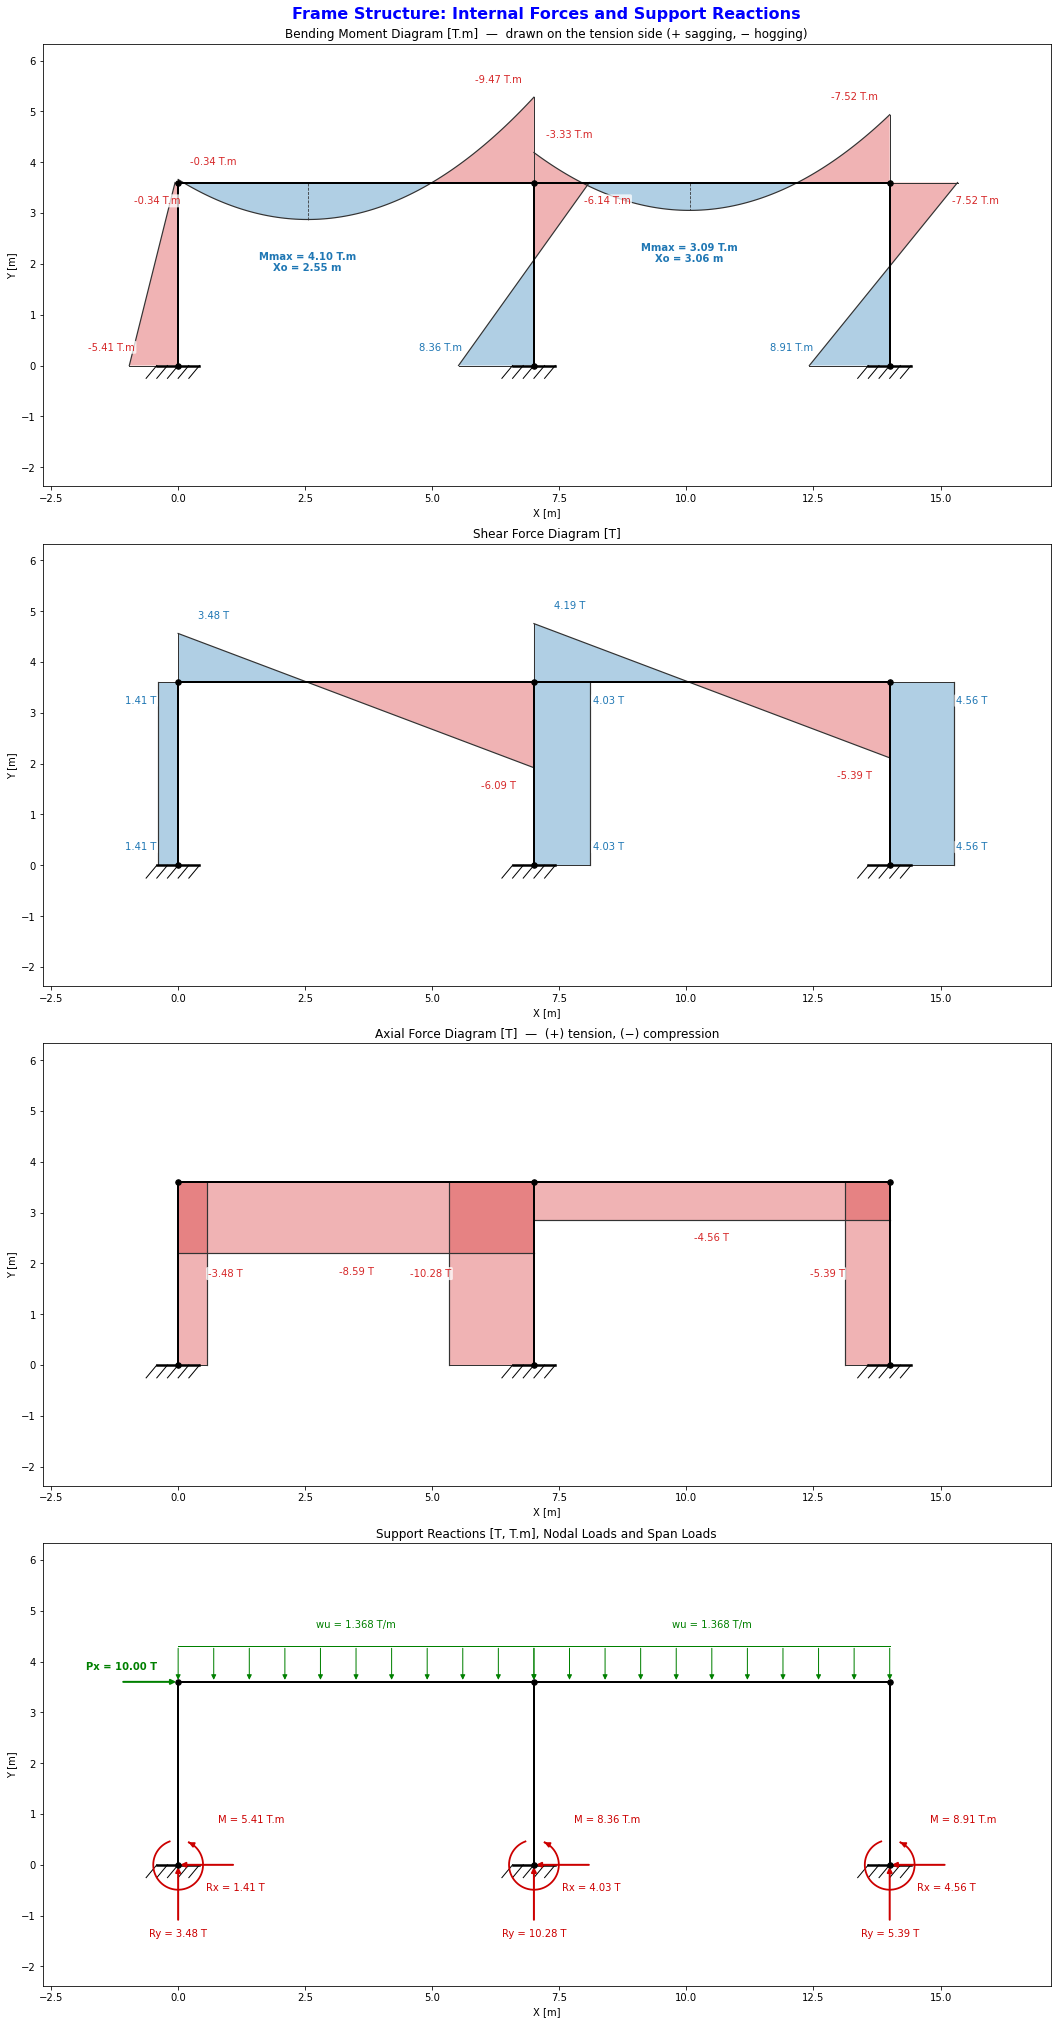

✅ Plotted reactions match the reactions of the structure.


In [33]:
plotIF = PlotInternalForces2D(CoordNode = CoordNode, Lee_Nodos = Lee_Nodos, Lee = Lee, Fe_L_all = Fe_L_all,         # Create internal forces plot object
                              wu_e = wu_e, gdl = gdl,                                                               # Element loads and number of free DOF
                              figsize = (20, 28),                                                                   # Figure size (width, height) [in]
                              color_sagging = '#1f77b4', color_hogging = '#d62728',                                 # Colors: sagging/tension (+) and hogging/compression (-)
                              P_nodal = P_nodal)                                                                    # External nodal loads (drawn in the reactions subplot)
plotIF.PlotIF_RMF()                                                                                                 # Plot moment, shear, axial and reactions

if np.allclose(plotIF.reactions, React_gdl_g):                                                                      # Check against S_RL @ delta_g
    print(f"\x1b[1;32m✅ Plotted reactions match the reactions of the structure.\x1b[0m")                            # Print success message with green color
else:
    print(f"\x1b[1;31m🚫 Plotted reactions do not match the reactions of the structure.\x1b[0m")                     # Print error message with red color